In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# ===============================
# Import Required Libraries
# ===============================

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Model evaluation metrics
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

# Statistical analysis
from scipy import stats

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

#Improve the Appearance of Graphs
# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")

# Set default color palette
sns.set_palette("husl")

In [10]:
# ============================================
# Load California Housing Dataset
# ============================================

try:

 url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

 df = pd.read_csv(url)
 print("Dataset loaded successfully from URL!")

except:

 print("URL download failed.")
 print("Generating synthetic dataset...")

 np.random.seed(42)

 n_samples = 5000

 df = pd.DataFrame({
  "longitude": np.random.uniform(-124.5, -114.5, n_samples),

  "latitude": np.random.uniform(32.5, 42.0, n_samples),

  "housing_median_age": np.random.randint(1, 52, n_samples),

  "total_rooms": np.random.normal(2000, 1000, n_samples).astype(int),
  "total_bedrooms": np.random.normal(500, 250, n_samples).astype(int),
  "population": np.random.normal(1200, 800, n_samples).astype(int),
  "households": np.random.normal(450, 250, n_samples).astype(int),
  "median_income": np.random.uniform(0.5, 15, n_samples),
  "median_house_value": np.random.normal(200000, 80000, n_samples).astype(int),
  "ocean_proximity": 
     np.random.choice(
         [
             "NEAR BAY",
             "<1H OCEAN",
             "INLAND",
             "NEAR OCEAN",
             "ISLAND"
         ],
         n_samples,
         p=[0.30, 0.30, 0.30, 0.09, 0.01]
     )
})

# Create a relationship between features and house price
 df["median_house_value"] = (

 df["median_income"] * 40000 +

 df["housing_median_age"] * 1000 +
 df["total_rooms"] * 20 +

 np.random.normal(0, 30000, n_samples)

 ).astype(int)

# Limit house values to realistic values
 df["median_house_value"] = df["median_house_value"].clip(
     lower=50000,
     upper=500001
)

 print("Synthetic dataset created successfully!")

Dataset loaded successfully from URL!


In [15]:
#shape of the dataset
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (20640, 10)


In [14]:
#the First Five Rows
print("First Five Rows:")
df.head()

First Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
print("Dataset Information")
print("-" * 50)

df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [16]:
#Statistical Summary
print("Statistical Summary")
print("-" * 50)

df.describe()

Statistical Summary
--------------------------------------------------


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [17]:
print("Missing Values")
print("-" * 50)

print(df.isnull().sum())

Missing Values
--------------------------------------------------
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [19]:
if df.isnull().sum().sum() > 0:
    print("Removing rows with missing values...")
    df = df.dropna()
    print(f"New Dataset Shape: {df.shape}")

Removing rows with missing values...
New Dataset Shape: (20433, 10)


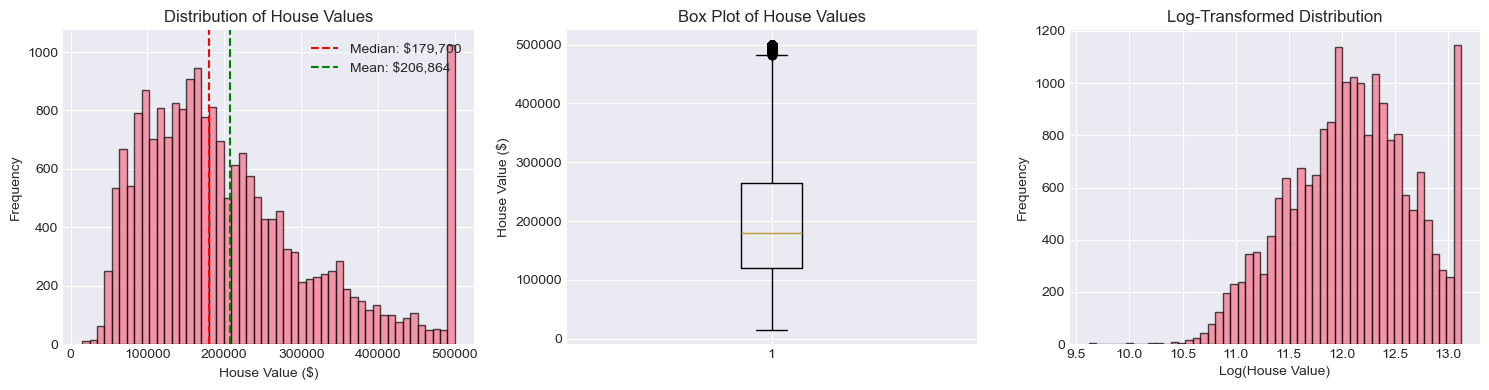

In [21]:
# Distribution by median_house_value.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --------------------------
# Histogram
# --------------------------

axes[0].hist(
    df["median_house_value"],
    bins=50,
    edgecolor="black",
    alpha=0.7
)

axes[0].set_title("Distribution of House Values")
axes[0].set_xlabel("House Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
    df["median_house_value"].median(),
    color="red",
    linestyle="--",
    label=f"Median: ${df['median_house_value'].median():,.0f}"
)

axes[0].axvline(
    df["median_house_value"].mean(),
    color="green",
    linestyle="--",
    label=f"Mean: ${df['median_house_value'].mean():,.0f}"
)

axes[0].legend()

# --------------------------
# Box Plot
# --------------------------

axes[1].boxplot(df["median_house_value"])
axes[1].set_title("Box Plot of House Values")
axes[1].set_ylabel("House Value ($)")

# --------------------------
# Log Transformation
# --------------------------

axes[2].hist(
    np.log1p(df["median_house_value"]),
    bins=50,
    edgecolor="black",
    alpha=0.7
)

axes[2].set_title("Log-Transformed Distribution")
axes[2].set_xlabel("Log(House Value)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()

plt.show()

In [23]:
#Correlation Analysis
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
    df[numeric_columns]
        .corr()["median_house_value"]
        .sort_values(ascending=False)
)
print("Top Correlations with House Price")
print(correlations)

Top Correlations with House Price
median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64


This graph helps identify which features have the strongest relationship with house prices.


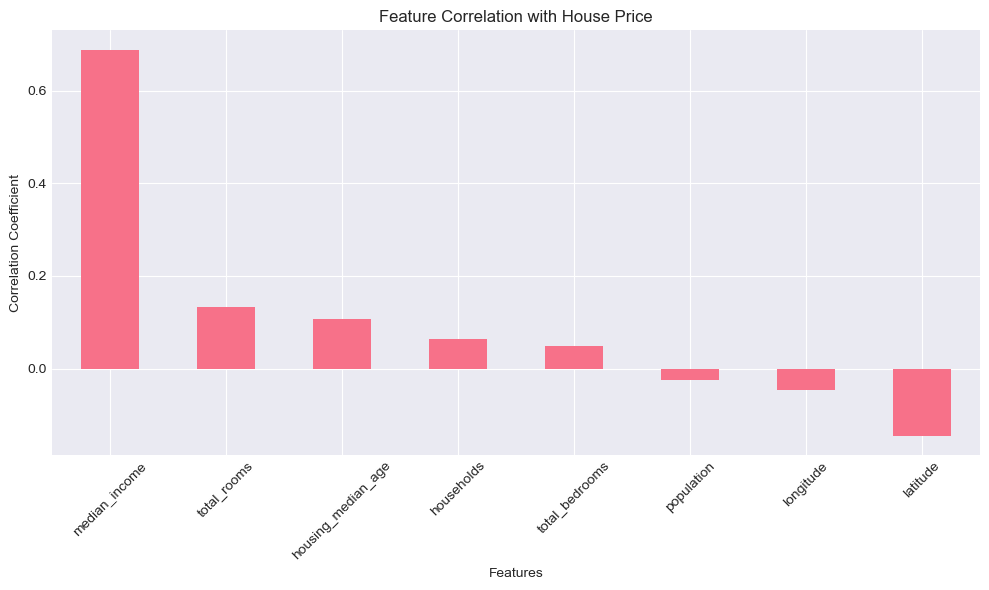

In [25]:
#Visualize Correlations
print("This graph helps identify which features have the strongest relationship with house prices.")
plt.figure(figsize=(10, 6))

correlations.drop("median_house_value").plot(kind="bar")

plt.title("Feature Correlation with House Price")

plt.xlabel("Features")

plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


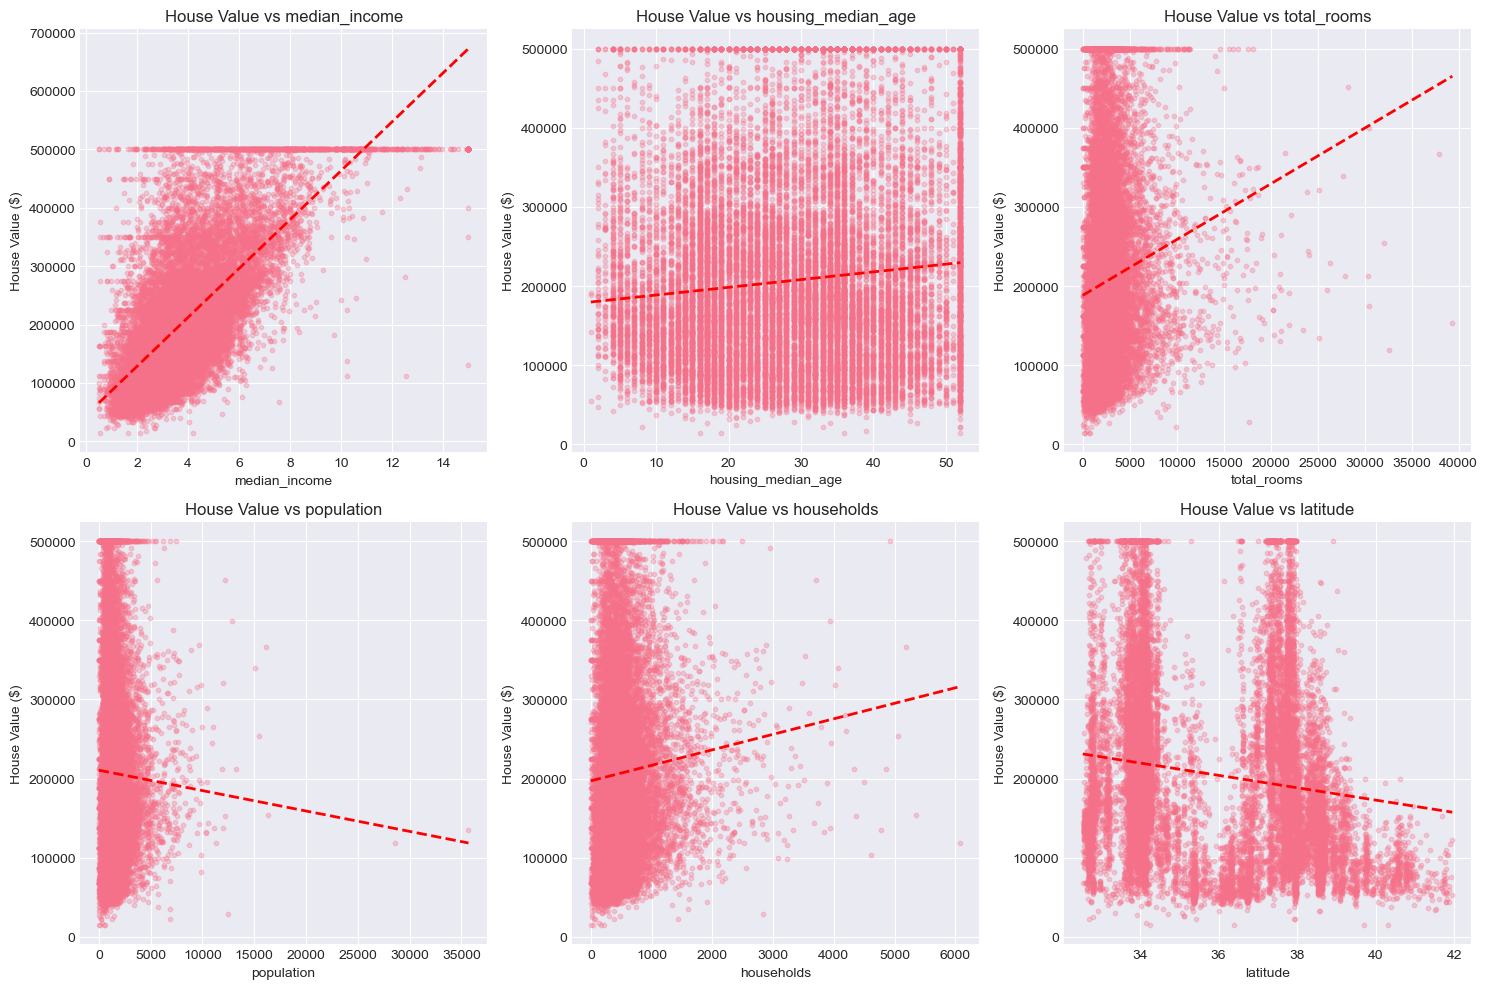

In [26]:
#Scatter Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population",
    "households",
    "latitude"
]

for index, feature in enumerate(features):
    row = index // 3
    column = index % 3
    
    axes[row, column].scatter(
        df[feature],
        df["median_house_value"],
        alpha=0.3,
        s=10
    )
    
    axes[row, column].set_title(f"House Value vs {feature}")
    axes[row, column].set_xlabel(feature)
    axes[row, column].set_ylabel("House Value ($)")
# Add linear trend line
    z = np.polyfit(df[feature], df["median_house_value"], 1)
    p = np.poly1d(z)
    
    axes[row, column].plot(
        df[feature].sort_values(),
        p(df[feature].sort_values()),
        "r--",
        linewidth=2
)

plt.tight_layout()

plt.show()

In [ ]:
1. Does the feature show a positive or negative relationship with house price?
posite on (1,2,3,4) negative on(4,6)
2. Is the relationship strong or weak?
3. Are there any outliers?
4. Which feature appears to have the greatest influence on house prices?